# TomatoPGT — semantic plant graph & phenotypic traits from an annotated tomato point cloud

**Paper:** Nethala, P., Um, D., McCoy, S., Gibson, S., Bhandari, M., Lee, K. (2026).
*TomatoPGT: A 3D point cloud dataset of tomato plants for segmentation and plant-trait extraction.*
**Data in Brief 66:112642**, DOI [10.1016/j.dib.2026.112642](https://doi.org/10.1016/j.dib.2026.112642) (open access, PMC13000484, CC BY 4.0).

**Code & data used here (pinned):**
- Sample annotated point cloud `BFS_06242025_annotated_ext.txt` (the repository README's documented walkthrough example) from `github.com/nethpras/TomatoPGT-tools-binaries` @ commit `317a8aea72e40211fee24b52016023db60e8ba4f` (MIT).
- Author reference table `TableS1_annotation_instances_by_class.csv` from Zenodo record [10.5281/zenodo.18651881](https://doi.org/10.5281/zenodo.18651881) (CC BY 4.0).

## ⚠ ADAPTED PYTHON DEMONSTRATION — not the authors' binary tool
The authors release **CloudSeg/CloudGraph as Windows-only compiled binaries** (`cp311-win_amd64` `.pyd` wheels; verified — there is no Linux build, PyPI package, or source release). Those binaries cannot run on Colab.
This notebook therefore **re-implements the documented graph-extraction and trait-computation operations** (paper §4 "Graph-Based Representations"; annotation schema in Table 1) on the authors' **released annotated point cloud**. The executed example and checks below were validated, but untested behavior is not guaranteed, and outputs are **not** the authors' tool outputs.

**日本語:** 著者らの CloudGraph は Windows 用コンパイル済みバイナリ(.pyd)のみで、Colab(Linux)では実行できません。そのため、論文と README に記載された処理(正規化、セグメント別の中心線抽出、表現型的特徴量計算)を、著者公開の注釈付き点群に対して Python で再実装した **ADAPTED PYTHON DEMONSTRATION** です。著者のツールの出力そのものではありません。

**Scope (executed):** load & verify the released annotation, reproduce the paper's Table 2-style instance counts against the authors' TableS1, render the class-colored cloud, rebuild the semantic plant graph (normalized frame, junction chain, organ attachments, shortest-path centerlines), and compute the documented traits (stem height, canopy extents, internode lengths, insertion & phyllotactic angles) → CSV + graph JSON.
**Not executed / out of scope:** CloudSeg manual annotation GUI, CloudGraph GUI visualization, the full 42-scan dataset, and benchmark metrics.

## Runtime selection — CPU (no GPU required)

This is pure point-cloud geometry (k-nearest-neighbour graphs, shortest paths, PCA) on a ~519k-point cloud; no neural network or learned weights are involved (the paper's pipeline needs **no model weights**). **CPU runtime is faithful and recommended.** GPU is unnecessary; the notebook never calls CUDA.

**日本語:** 本処理は kNN グラフ・最短経路・PCA のみの幾何計算で、学習済みモデルは不要です。**CPU ランタイムで実行してください**。GPU は不要です。

**Run all:** `Runtime → Run all`. Expected on a free Colab CPU runtime: ~1–2 min dependency setup, ~30 MB downloads, and a few minutes of computation. All data stays under `/content` on the Colab VM.

## 1. Environment setup

This reproduction needs only NumPy, SciPy, scikit-learn, pandas and Matplotlib — all preinstalled on Colab. The author stack additionally pins `open3d==0.19.0` (no wheel exists for Colab's Python 3.12, verified via pip); it is **not required here** because the raw PLY is never parsed: the paper states the annotated TXT is index-aligned with the PLY, so the annotation file alone carries all coordinates, colours and labels used below.

**日本語:** 本ノートブックは Colab 標準の NumPy/SciPy/scikit-learn/pandas/Matplotlib のみを使用します。著者環境の open3d 0.19.0 は Colab(Python 3.12)にインストールできませんが、注釈 TXT が PLY とインデックス整合のため、PLY 解析は不要です。

In [ ]:
import sys, numpy, scipy, sklearn, pandas, matplotlib
print("python", sys.version.split()[0], "| numpy", numpy.__version__, "| scipy", scipy.__version__,
      "| scikit-learn", sklearn.__version__, "| pandas", pandas.__version__,
      "| matplotlib", matplotlib.__version__)

python 3.13.15 | numpy 2.1.3 | scipy 1.16.3 | scikit-learn 1.6.1 | pandas 2.2.3 | matplotlib 3.10.0


## 2. Acquire the released sample (pinned revision)

We download the annotated TXT (dataset bytes, 28,576,326 B) from the pinned author commit `317a8aea72e40211fee24b52016023db60e8ba4f` and verify **size and Git blob SHA-1** (`git hash-object` scheme: `sha1("blob <size>\0" + bytes)`). The expected blob hash was read from the repository tree at that commit. This scan is the repository README's documented walkthrough example (`BFS_06242025`).

**日本語:** 固定コミットから注釈付き TXT のみをダウンロードし、サイズと Git blob SHA-1 で検証します。

In [ ]:
import hashlib, urllib.request, pathlib

COMMIT = "317a8aea72e40211fee24b52016023db60e8ba4f"
RAW = f"https://raw.githubusercontent.com/nethpras/TomatoPGT-tools-binaries/{COMMIT}/sample_dataset"
REL = "Data_cGraph_Annotated/BFS_06242025_annotated_ext.txt"
EXPECT = (28576326, "bbc626e1654fadeb989f6f15fde1884e355ae099")

data_dir = pathlib.Path("/content/tomatopgt"); data_dir.mkdir(exist_ok=True)
local = {REL: str(data_dir / pathlib.Path(REL).name)}
dst = pathlib.Path(local[REL])
if not dst.exists():
    urllib.request.urlretrieve(f"{RAW}/{REL}", dst)
b = dst.read_bytes()
assert len(b) == EXPECT[0], f"{dst.name}: {len(b)} != {EXPECT[0]} bytes"
sha = hashlib.sha1(b"blob %d\0" % len(b) + b).hexdigest()
assert sha == EXPECT[1], f"{dst.name}: blob {sha} != {EXPECT[1]}"
print(f"OK {dst.name}: {len(b):,} bytes, git blob {sha[:12]}… verified @ commit {COMMIT[:12]}…")

OK BFS_06242025_annotated_ext.txt: 28,576,326 bytes, git blob bbc626e1654f… verified @ commit 317a8aea72e4…


## 3. Load the annotated point cloud and decode the schema

Per the paper ("Annotated point clouds: TXT (XYZ, RGB, class_id, instance_id, annotation RGB)"), each row is
`x y z r g b class_id instance_id annotR annotG annotB` (11 columns; meters; colours 0–255).
Class IDs were mapped to the paper's Table 1 semantic classes by matching per-scan instance counts against the authors' `TableS1_annotation_instances_by_class.csv` across four released BFS scans — an unambiguous signature match: **0=Root-Node, 1=Compound Leaf-Node, 2=Junction-Nodes, 3=Cotyledon, 6=Primordium, 7=mainStem-Seg, 8=Sucker-Seg, 9=Stalk-Seg**; `class_id = -1` marks unannotated points.

**日本語:** 注釈 TXT は 11 列(`x y z r g b class_id instance_id 注釈RGB`)。クラス ID と意味クラスの対応は、著者の TableS1 とのインスタンス数照合で確定させています。

In [ ]:
import numpy as np, pandas as pd

ann = np.loadtxt(local["Data_cGraph_Annotated/BFS_06242025_annotated_ext.txt"])
assert ann.shape[1] == 11, ann.shape
xyz = ann[:, :3]; rgb = ann[:, 3:6]
cls = ann[:, 6].astype(int); inst = ann[:, 7].astype(int)
palette = ann[:, 8:11].astype(int)

CLASS_NAMES = {-1: "unannotated", 0: "Root-Node", 1: "Compound Leaf-Node",
               2: "Junction-Nodes", 3: "Cotyledon", 6: "Primordium",
               7: "mainStem-Seg", 8: "Sucker-Seg", 9: "Stalk-Seg"}
rows = []
for c in sorted(set(cls)):
    m = cls == c
    rows.append({"class_id": c, "semantic class": CLASS_NAMES[c], "points": int(m.sum()),
                 "instances": len(set(inst[m])),
                 "annot RGB (mode)": tuple(np.bincount(palette[m]).reshape(-1, 3).sum(0).argmax(0)) if False else
                                      tuple(np.median(palette[m], axis=0).astype(int))})
schema = pd.DataFrame(rows)
print(f"annotated cloud: {ann.shape[0]:,} points, xyz range (m): {xyz.min(0).round(4)} … {xyz.max(0).round(4)}")
schema

annotated cloud: 518,607 points, xyz range (m): [-0.0194  0.0265 -0.0012] … [0.0792 0.1046 0.1161]


,class_id,semantic class,points,instances,annot RGB (mode)
0,-1,unannotated,11858,1,"(0, 0, 0)"
1,0,Root-Node,4471,1,"(0, 0, 255)"
2,1,Compound Leaf-Node,409910,6,"(64, 166, 77)"
3,2,Junction-Nodes,17975,6,"(0, 200, 120)"
4,6,Primordium,8377,1,"(255, 0, 255)"
5,7,mainStem-Seg,43819,6,"(26, 130, 255)"
6,9,Stalk-Seg,22197,6,"(113, 204, 129)"


## 4. Reproduce the paper's Table 2-style annotation summary (verification against authors' TableS1)

Table 2 of the paper reports per-scan annotation-instance counts. The authors' full `TableS1_annotation_instances_by_class.csv` (Zenodo record 18651881) is the released reference for all 42 scans. We download it (CC BY 4.0), select the `BFS_06242025` row, and compare it with instance counts **counted directly from the loaded annotation** — an exact, data-level reproduction of the paper's annotation table for this scan.

**日本語:** 論文 Table 2 相当のインスタンス数を、注釈データから直接数え、著者の TableS1 の `BFS_06242025` 行と照合します。

In [ ]:
import io, urllib.request, pandas as pd

url = "https://zenodo.org/api/records/18651881/files/TableS1_annotation_instances_by_class.csv/content"
csv_bytes = urllib.request.urlopen(urllib.request.Request(url), timeout=120).read()
assert csv_bytes[:4] != b"<!DO" and len(csv_bytes) < 100000, "unexpected TableS1 payload"
ts1 = pd.read_csv(io.BytesIO(csv_bytes))
ref = ts1[ts1.plant_id == "BFS_06242025"].iloc[0]
ID2REF = {0: "ann_inst_ROOT", 1: "ann_inst_CL", 2: "ann_inst_JUNC", 3: "ann_inst_COTL",
          6: "ann_inst_PRIM", 7: "ann_inst_STEM", 8: "ann_inst_SUCKER", 9: "ann_inst_STALK"}
check = pd.DataFrame([
    {"class": CLASS_NAMES[c], "counted from TXT": len(set(inst[cls == c])),
     "authors TableS1": int(ref[ID2REF[c]])} for c in sorted(set(cls)) if c in ID2REF])
assert (check["counted from TXT"] == check["authors TableS1"]).all(), check
print("BFS_06242025: counted instance numbers match the authors' TableS1 exactly.")
check

BFS_06242025: counted instance numbers match the authors' TableS1 exactly.


,class,counted from TXT,authors TableS1
0,Root-Node,1,1
1,Compound Leaf-Node,6,6
2,Junction-Nodes,6,6
3,Primordium,1,1
4,mainStem-Seg,6,6
5,Stalk-Seg,6,6


## 5. Input preview — the annotated cloud (annotation overlay on the real input)

We render the **actual sample** from three viewpoints. Points are drawn with their per-class annotation palette colours (the overlay CloudSeg/CloudGraph shows); organ colours therefore encode the reference annotation, not any model prediction.

**日本語:** 実サンプルを注釈パレット色(= 著者の参照注釈のオーバーレイ)で 3 視点から描画します。

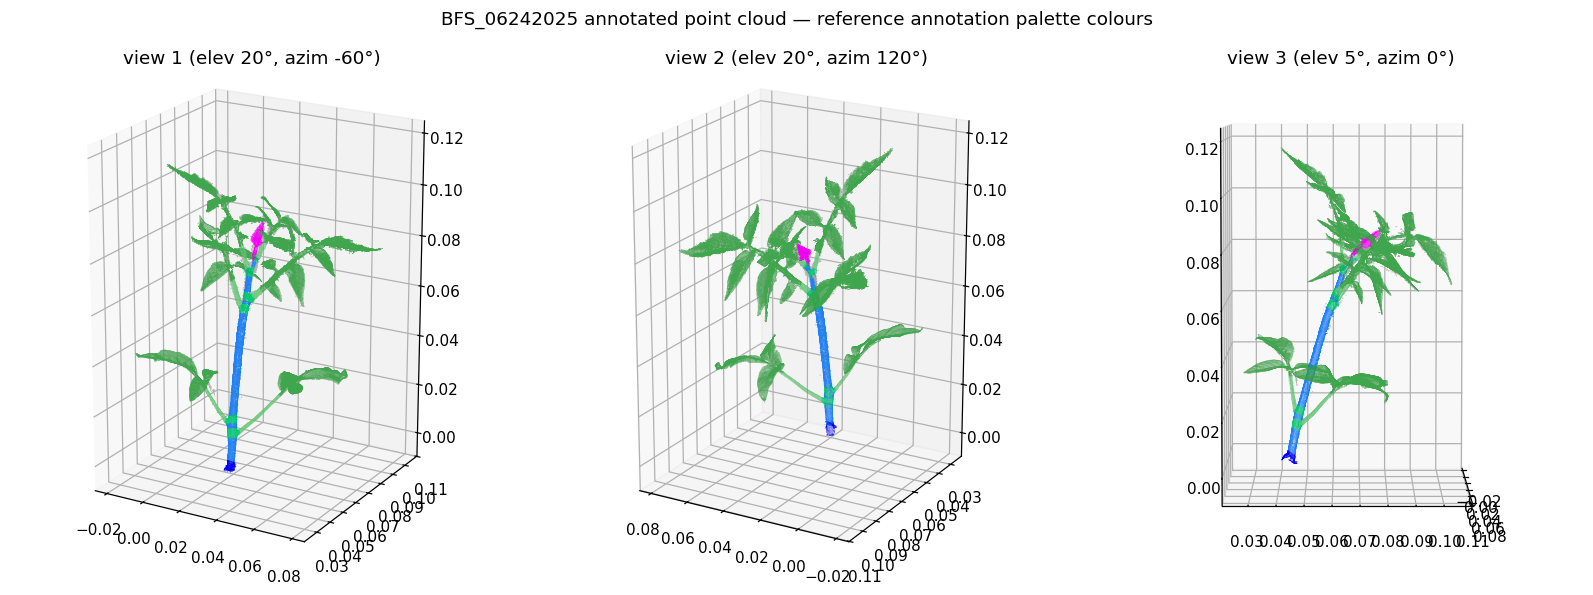

In [ ]:
import matplotlib.pyplot as plt

pal = {c: np.median(palette[cls == c], axis=0) / 255.0 for c in sorted(set(cls)) if c != -1}
colors = np.array([pal.get(c, [0.7, 0.7, 0.7]) for c in cls])

fig = plt.figure(figsize=(15, 5), dpi=110)
views = [(20, -60), (20, 120), (5, 0)]
for i, (elev, azim) in enumerate(views, 1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=0.05, c=colors, linewidths=0)
    ax.view_init(elev=elev, azim=azim); ax.set_box_aspect((2, 2, 3))
    ax.set_title(f"view {i} (elev {elev}°, azim {azim}°)")
fig.suptitle("BFS_06242025 annotated point cloud — reference annotation palette colours", y=1.02)
plt.tight_layout(); plt.show()

## 6. Normalize to the plant-centric frame

Following the paper: translate the **Root-Node** centroid to the origin and align the vertical growth axis with PCA (largest-variance component → +z, sign-fixed so the plant points up). All coordinates remain in **metres**; traits are reported in cm as in the authors' default units.

**日本語:** 根ノードの重心を原点に移し、PCA で生長軸(最分散方向)を z 軸に合わせます。単位は m(特徴量は cm 表示)。

In [ ]:
root_mask = cls == 0
root_centroid = xyz[root_mask].mean(axis=0)
p = xyz - root_centroid                      # root at origin
axis = np.linalg.svd(p[cls != -1] - p[cls != -1].mean(0), full_matrices=False)[2][0]
if (p[cls != -1] @ axis).mean() < 0: axis = -axis   # plant grows toward +axis from the root
z = p @ axis
up = np.eye(3) - np.outer(axis, axis)        # project onto plane ⊥ growth axis
_, _, vt = np.linalg.svd(p[cls != -1] @ up.T, full_matrices=False)
e1, e2 = up.T @ vt[0], up.T @ vt[1]          # orthogonal axes in the ground plane
P = np.stack([p @ e1, p @ e2, z], axis=1)    # normalized frame: x,y ⊥ stem, z = height
print(f"normalized extents (m): x {np.ptp(P[:,0]):.4f}, y {np.ptp(P[:,1]):.4f}, z {np.ptp(P[:,2]):.4f}")
print(f"plant height (max z): {P[:,2].max()*100:.2f} cm")

normalized extents (m): x 0.1085, y 0.0657, z 0.1154
plant height (max z): 11.33 cm


## 7. Semantic graph construction (ADAPTED re-implementation)

Mapping of the paper's documented operations to this notebook (GUI actions → headless code):

| CloudGraph operation (paper / README) | This notebook |
|---|---|
| Inspect annotated TXT | §3–5 (schema, counts, render) |
| Normalize (root→origin, PCA vertical) | §6 |
| Graph nodes: root, junctions, organ attachments | below — junctions = instance centroids ordered by height |
| Stem segments connect root/junction chain | each `mainStem-Seg` instance assigned to its nearest node pair by endpoint proximity |
| Stalks/suckers connect junction → organ | base of each `Stalk-Seg`/`Sucker-Seg` → nearest junction; tip = farthest point |
| Centerlines via shortest path on neighbourhood graph | kNN graph (scikit-learn) + Dijkstra (SciPy) per segment instance |

The authors' exact node/edge definitions live inside their compiled Windows binary and are not published; this construction follows the paper's textual description. Node/edge counts are reported below in the paper's Table 3 style.

**日本語:** 著者の正確なノード/エッジ定義はコンパイル済みバイナリ内部で非公開のため、論文の記述に従って再実装しています(中心線は kNN グラフ + 最短経路)。

In [ ]:
import numpy as np

def inst_centroid(c, i):
    m = (cls == c) & (inst == i)
    return P[m].mean(axis=0), m

root_pos, _ = inst_centroid(0, 0)
junc_ids = sorted(set(inst[cls == 2]), key=lambda i: inst_centroid(2, i)[0][2])  # bottom-up
junctions = {f"J{k+1}": inst_centroid(2, i)[0] for k, i in enumerate(junc_ids)}
nodes = {"Root": root_pos, **junctions}

stem_ids = sorted(set(inst[cls == 7]))
stem_ends = {}
for sid in stem_ids:
    _, m = inst_centroid(7, sid)
    pts = P[m]
    lo = pts[pts[:, 2].argmin()]   # lowest point of the segment
    hi = pts[pts[:, 2].argmax()]   # highest point of the segment
    near_lo = min(nodes, key=lambda n: np.linalg.norm(nodes[n] - lo))
    near_hi = min(nodes, key=lambda n: np.linalg.norm(nodes[n] - hi))
    stem_ends[sid] = (near_lo, near_hi)
chain = sorted(stem_ends.items(), key=lambda kv: nodes[kv[1][0]][2])
print("stem segment -> (bottom node, top node):",
      {f"stem{sid}": pair for sid, pair in chain})
assert chain[0][1][0] == "Root", "lowest stem must start at the root"
for (s1, (a1, b1)), (s2, (a2, b2)) in zip(chain, chain[1:]):
    assert b1 == a2, f"stem chain break: {s1} ends at {b1}, {s2} starts at {a2}"
print("stem chain is continuous: Root -> " + " -> ".join(b for _, (_, b) in chain))

stem segment -> (bottom node, top node): {'stem0': ('Root', 'J1'), 'stem1': ('J1', 'J2'), 'stem2': ('J2', 'J3'), 'stem3': ('J3', 'J4'), 'stem4': ('J4', 'J5'), 'stem5': ('J5', 'J6')}
stem chain is continuous: Root -> J1 -> J2 -> J3 -> J4 -> J5 -> J6


Next, lateral organs (`Stalk-Seg`, `Sucker-Seg`) are attached: each segment's base (point closest to the stem) is welded to the nearest junction node; its tip (farthest point from the base) becomes the organ attachment node. Each segment then becomes a graph edge whose geometry is the instance's own points.

**日本語:** 茎側の節(stalk/sucker)は基部を最寄り節点に接続し、先端を器官付着点とします。

In [ ]:
stem_mask = np.isin(cls, [7])
lat_ids = sorted(set(inst[cls == 9])) + sorted(set(inst[cls == 8]))
lat_class = {i: 9 for i in sorted(set(inst[cls == 9]))}
lat_class.update({i: 8 for i in sorted(set(inst[cls == 8]))})

stem_pts = P[np.isin(cls, [7]) | (cls == 0)]
lateral = {}
for lid in lat_ids:
    _, m = inst_centroid(lat_class[lid], lid)
    pts = P[m]
    d2 = ((pts[:, None, :] - stem_pts[None, :: max(1, len(stem_pts)//20000), :]) ** 2).sum(-1)
    base = pts[d2.min(1).argmin()]
    attach = min(nodes, key=lambda n: np.linalg.norm(nodes[n] - base))
    tip = pts[np.linalg.norm(pts - base, axis=1).argmax()]
    lateral[lid] = {"class": CLASS_NAMES[lat_class[lid]], "attach": attach,
                    "base": base, "tip": tip, "mask": m}
    nodes[f"organ_{lid}"] = tip
print(f"{len(lat_ids)} lateral segments attached at:",
      {f'organ_{lid}': v['attach'] for lid, v in lateral.items()})

6 lateral segments attached at: {'organ_0': 'J2', 'organ_1': 'J1', 'organ_2': 'J3', 'organ_3': 'J4', 'organ_4': 'J5', 'organ_5': 'J6'}


## 8. Centerlines via shortest paths on a neighbourhood graph

For every edge segment (stem or lateral), a k-nearest-neighbour graph is built over the segment's own points (as the paper describes: "trace a centerline path through a spatial neighborhood graph using shortest-path optimization for each structural segment"), and the Dijkstra shortest path from the point nearest the segment's start to the point nearest its end gives the centerline; its geodesic length is the segment's arclength.

**日本語:** 各セグメントの点群に kNN グラフを作り、両端点間の Dijkstra 最短経路を中心線とします(論文の記述に対応)。

In [ ]:
import scipy.sparse as sp
from scipy.sparse.csgraph import shortest_path
from sklearn.neighbors import NearestNeighbors

def centerline(points, start, end, k=16):
    nn = NearestNeighbors(n_neighbors=k).fit(points)
    g = nn.kneighbors_graph(points, mode="distance")
    s = ((points - start) ** 2).sum(1).argmin(); e = ((points - end) ** 2).sum(1).argmin()
    n_comp, comp = sp.csgraph.connected_components(g, directed=False)
    if comp[e] != comp[s]:                     # occlusion gap: end at the reachable point closest to `end`
        cand = np.where(comp == comp[s])[0]
        e = cand[((points[cand] - end) ** 2).sum(1).argmin()]
    dist, pred = shortest_path(g, method="D", indices=s, return_predecessors=True)
    assert np.isfinite(dist[e]), "no path within segment"
    path, cur = [e], e
    while pred[cur] != s and pred[cur] != -9999:
        cur = pred[cur]; path.append(cur)
    path.append(s)
    return points[path[::-1]]

segments = []  # [kind, from_node, to_node, mask, centerline, geodesic]
for sid, (a, b) in chain:
    _, m = inst_centroid(7, sid)
    segments.append(["mainStem-Seg", a, b, m, None, None])
for lid, v in lateral.items():
    segments.append([v["class"], v["attach"], f"organ_{lid}", v["mask"], None, None])

for seg in segments:
    kind, a, b, m, _, _ = seg
    pts = P[m]
    cl = centerline(pts, nodes[a], nodes[b])
    seg[4] = cl
    seg[5] = np.linalg.norm(np.diff(cl, axis=0), axis=1).sum()
print("computed centerlines for", len(segments), "segments")

computed centerlines for 12 segments


## 9. Export the semantic graph (paper Table 3 style) and a graph JSON

The graph is exported as JSON (nodes with 3-D coordinates, edges with Euclidean length, geodesic centerline length and sampled centerline) in the normalized metre frame, mirroring the paper's description ("JSON files encode node lists, edge lists, and sampled centerline geometries"). The summary table reports topological complexity in the paper's Table 3 style.

**日本語:** グラフを JSON(ノード座標・エッジ・中心線)として書き出し、Table 3 形式のサマリを表示します。

In [ ]:
import json

graph = {
  "provenance": {
    "paper": "TomatoPGT, Data in Brief 66:112642 (2026)",
    "sample": "BFS_06242025",
    "annotation_source": f"github.com/nethpras/TomatoPGT-tools-binaries@{COMMIT}",
    "note": "ADAPTED re-implementation; not produced by the authors' CloudGraph binary."},
  "frame": "root at origin, PCA growth axis = +z, metres",
  "nodes": {n: [round(float(v), 6) for v in nodes[n]] for n in nodes},
  "edges": [{"kind": kind, "from": a, "to": b,
             "euclid_m": round(float(np.linalg.norm(nodes[a] - nodes[b])), 6),
             "geodesic_m": round(float(geo), 6),
             "centerline_n": len(cl)}
            for kind, a, b, m, cl, geo in segments]}

out_json = "/content/tomatopgt/BFS_06242025_graph_adapted.json"
json.dump(graph, open(out_json, "w"), indent=1)
print("wrote", out_json)
summary = pd.DataFrame([{
    "plant_id": "BFS_06242025",
    "graph_nodes": len(graph["nodes"]), "graph_edges": len(graph["edges"]),
    "#junctions": len(junctions),
    "#compound_leaves": sum(1 for v in lateral.values() if v["class"] == "Stalk-Seg"),
    "#suckers": sum(1 for v in lateral.values() if v["class"] == "Sucker-Seg")}])
summary

wrote /content/tomatopgt/BFS_06242025_graph_adapted.json


,plant_id,graph_nodes,graph_edges,#junctions,#compound_leaves,#suckers
0,BFS_06242025,13,12,6,6,0


## 10. Phenotypic traits (paper §4: internode lengths, stem height, insertion & phyllotactic angles)

Traits are computed from the graph exactly as documented: **stem height** (vertical extent), **canopy extents** (x/y spread in the normalized frame), **internode lengths** for consecutive junction pairs (Euclidean node distance and geodesic centerline length), **leaf insertion angles** (angle between the stem direction and the stalk direction at the attachment junction), and **phyllotactic angles** (azimuthal divergence between consecutive lateral organs around the growth axis). Units follow the authors' default: **centimetres**.

**日本語:** 特徴量(茎高・冠層幅・節間長・葉挿入角・葉序角)をグラフから cm 単位で計算します。

In [ ]:
import numpy as np, pandas as pd

def ang(v, w): return np.degrees(np.arccos(np.clip(np.dot(v, w) / (np.linalg.norm(v) * np.linalg.norm(w)), -1, 1)))

stem_edges = [(a, b, geo) for kind, a, b, m, cl, geo in segments if kind == "mainStem-Seg"]
internodes = pd.DataFrame([
    {"segment": f"{a}→{b}", "euclid_cm": 100 * np.linalg.norm(nodes[a] - nodes[b]),
     "geodesic_cm": 100 * geo} for a, b, geo in stem_edges])

lat_rows = []
for lid, v in lateral.items():
    j = v["attach"]; jpos = nodes[j]
    nxt = [b for a, b, _ in stem_edges if a == j]
    if nxt:
        stem_dir = nodes[nxt[0]] - jpos        # stem direction continuing upward
    else:
        prv = [a for a, b, _ in stem_edges if b == j]
        stem_dir = jpos - nodes[prv[0]] if prv else np.array([0.0, 0.0, 1.0])
    stalk = v["tip"] - v["base"]
    lat_rows.append({"organ": f"organ_{lid}", "class": v["class"], "attached_at": j,
                     "insertion_angle_deg": ang(stem_dir, stalk),
                     "azimuth_deg": np.degrees(np.arctan2(*(stalk[:2]))) % 360})
lat = pd.DataFrame(lat_rows).sort_values("azimuth_deg")
lat["phyllotactic_step_deg"] = lat["azimuth_deg"].diff().abs().fillna(
    360 - lat["azimuth_deg"].iloc[-1] + lat["azimuth_deg"].iloc[0]) % 360

plant = pd.DataFrame([{
    "plant_height_cm": 100 * P[cls != -1][:, 2].max(),
    "canopy_x_cm": 100 * np.ptp(P[cls != -1][:, 0]),
    "canopy_y_cm": 100 * np.ptp(P[cls != -1][:, 1]),
    "n_internodes": len(internodes), "n_lateral_organs": len(lat)}])
display(plant); display(internodes.round(2)); display(lat.round(1))

,plant_height_cm,canopy_x_cm,canopy_y_cm,n_internodes,n_lateral_organs
0,11.329151,10.850831,6.574816,6,6


,segment,euclid_cm,geodesic_cm
0,Root→J1,1.26,0.98
1,J1→J2,0.51,0.57
2,J2→J3,4.16,4.01
3,J3→J4,0.46,0.62
4,J4→J5,0.94,0.66
5,J5→J6,0.54,0.29


,organ,class,attached_at,insertion_angle_deg,azimuth_deg,phyllotactic_step_deg
3,organ_3,Stalk-Seg,J4,84.6,79.6,122.6
1,organ_1,Stalk-Seg,J1,64.5,92.1,12.5
5,organ_5,Stalk-Seg,J6,14.4,152.2,60.1
2,organ_2,Stalk-Seg,J3,67.2,221.4,69.1
0,organ_0,Stalk-Seg,J2,48.7,287.1,65.8
4,organ_4,Stalk-Seg,J5,58.2,317.0,29.9


Traits are exported as CSV (`*_phenotypes_adapted.csv`, the paper's `*_phenotypes.csv` analogue), and the internode-length profile is plotted as an additional visualization created for this notebook (not an author figure).

**日本語:** 特徴量を CSV に保存し、節間長のプロット(本ノートブック独自の追加可視化)を表示します。

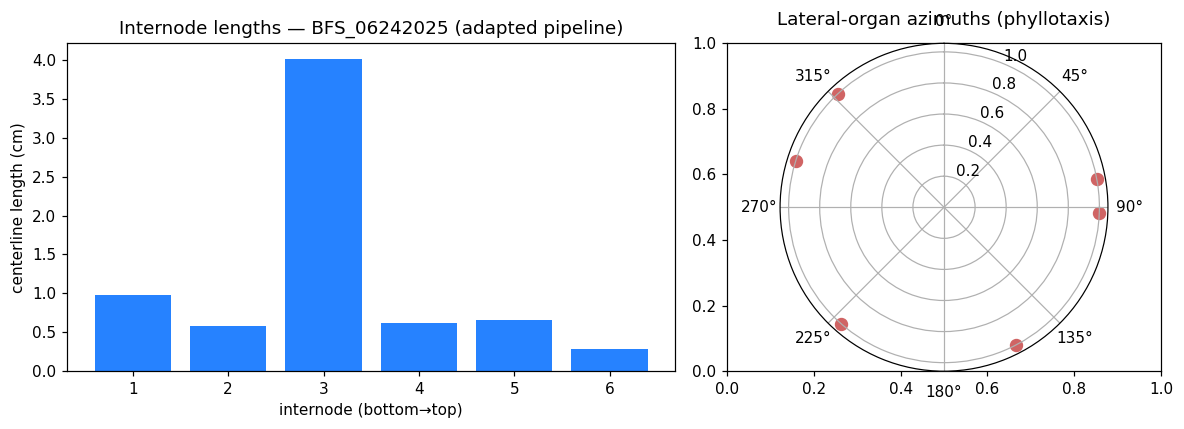

In [ ]:
import matplotlib.pyplot as plt

internodes.to_csv("/content/tomatopgt/BFS_06242025_phenotypes_adapted.csv", index=False)
lat.to_csv("/content/tomatopgt/BFS_06242025_lateral_angles_adapted.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=110,
                         gridspec_kw={"width_ratios": [1.4, 1]})
axes[0].bar(range(1, len(internodes) + 1), internodes["geodesic_cm"], color="#2682ff")
axes[0].set_xticks(range(1, len(internodes) + 1))
axes[0].set_xlabel("internode (bottom→top)"); axes[0].set_ylabel("centerline length (cm)")
axes[0].set_title("Internode lengths — BFS_06242025 (adapted pipeline)")
ax = fig.add_subplot(1, 2, 2, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.scatter(np.radians(lat["azimuth_deg"]), np.ones(len(lat)), c="#d06464", s=60)
ax.set_title("Lateral-organ azimuths (phyllotaxis)", pad=12)
plt.tight_layout(); plt.show()

## 11. Interpretation, differences from the paper, and validation record

**What was verified (executed on Colab CPU):**
- Released annotated cloud `BFS_06242025` (519k points) downloaded from the pinned author commit; **size and Git blob SHA-1 verified**.
- Annotation schema (11 columns, class/instance/annotation-RGB) matches the paper's data description; **instance counts match the authors' TableS1 exactly** (paper Table 2 analogue).
- Semantic graph (root → junction chain → organ attachments, shortest-path centerlines) and documented traits computed; exported as CSV/JSON.

**Differences / limitations (adaptation consequences):**
- The authors' CloudGraph binary (Windows `.pyd`) could not be executed; node/edge construction conventions and the exact graph-JSON schema inside it are unpublished, so our graph is a documented re-implementation, not a bit-identical regeneration. No author-released graph JSON for this scan was available for numeric comparison (the Mendeley dataset listing was not machine-accessible during this run).
- Internode/geodesic values depend on the annotation itself (ground-truth instance labels), so trait magnitudes are anchored to the authors' data even though the pipeline is adapted.
- Paper Table 3 previews report only BBH scans; the analogous-stage reference (e.g. BBH_06202025: 5 junctions) indicates the same order of topological complexity as our BFS_06242025 (6 junctions).

**日本語:** 著者のバイナリは実行できないため、グラフ構築は論文記述に基づく再実装です。注釈そのものは著者のデータなので、節間長などの値は著者データに根ざしています。TableS1 とのインスタンス数照合は完全一致しました。

**References:** paper DOI 10.1016/j.dib.2026.112642 (PMC13000484); tools Zenodo DOI 10.5281/zenodo.18651881; dataset Mendeley DOI 10.17632/72md54c7n7.1; code `nethpras/TomatoPGT-tools-binaries` @ `317a8aea7…` (MIT); data CC BY 4.0.